In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Hurricanes.csv", separator=";")

df = standardize_columns(df, columns=["femininity"])

In [3]:
with pm.Model() as model:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)


    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha + beta*femininity))

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample priors
    basic_prior_predictive = pm.sample_prior_predictive(var_names=["deaths", "expected_count"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior, var_names=["deaths", "expected_count"])
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, alpha_dispersion, beta, deaths]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [deaths]


Output()

Output()

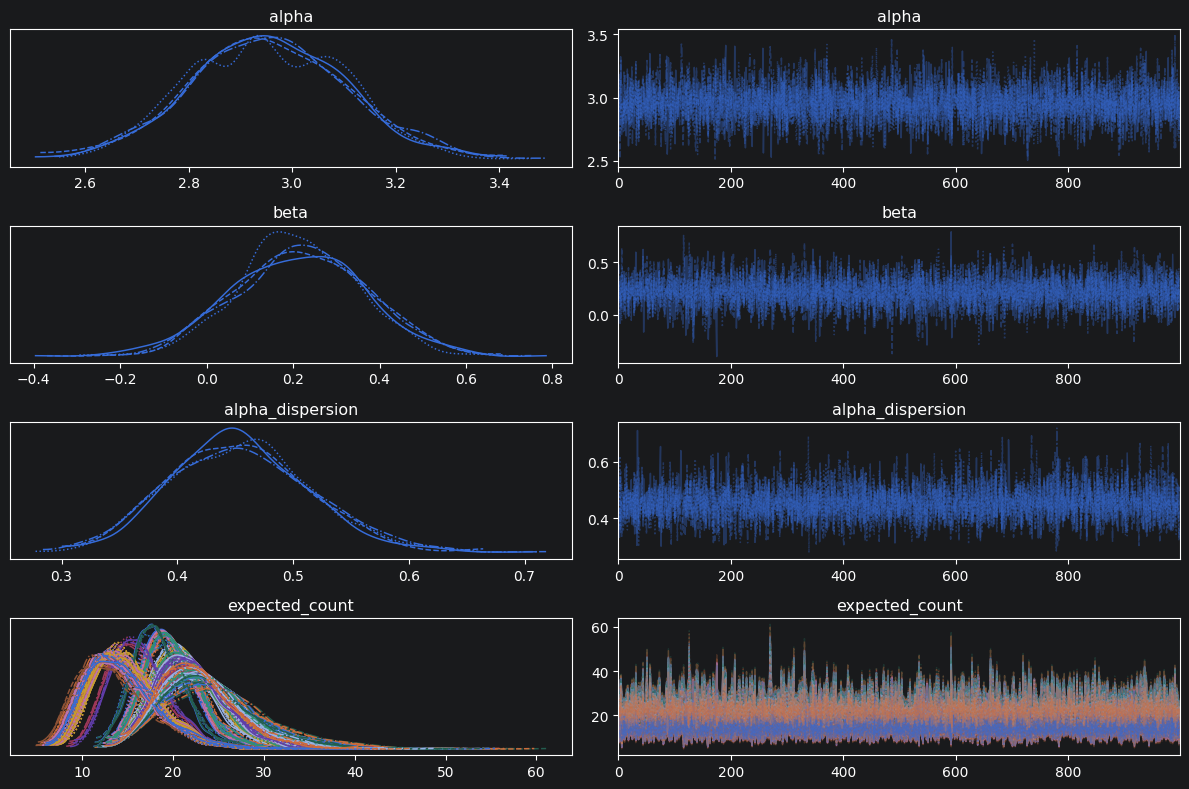

In [5]:
plot_trace(posterior)

<Axes: >

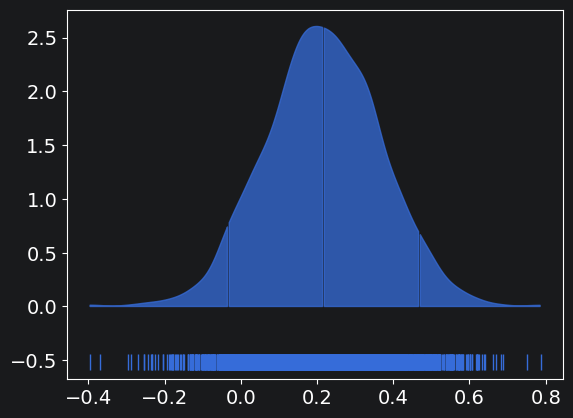

In [13]:
az.plot_dist(posterior.posterior['beta'], rug=True, quantiles=[.05, .5, 0.95])